In [ ]:
# ============================================================
# CELL 1 — Colab setup (Summarization RLHF: BT preferences + KL + ROUGE-L reward)
# ============================================================
# This notebook will demonstrate end-to-end RLHF on a *summarization* task:
#   (1) Train a base SFT summarizer policy  π_SFT
#   (2) Create preference pairs (chosen vs rejected) using ROUGE-L as the
#       "human feedback" signal (synthetic preference labeling)
#   (3) Train a reward model r_θ with Bradley–Terry loss on those pairs
#   (4) RL optimize π using a KL penalty to a frozen reference π_ref (= π_SFT)
#
# Reward signal we care about: ROUGE-L (we'll compute it with `evaluate`).

!nvidia-smi -L

# Core stack (Colab-friendly)
!pip -q install -U \
  "torch>=2.1" \
  "transformers>=4.41" \
  "datasets>=2.19" \
  "accelerate>=0.30" \
  "trl>=0.9" \
  "peft>=0.11" \
  "bitsandbytes>=0.43" \
  "evaluate>=0.4" \
  "rouge_score" \
  "tqdm" \
  "rich"

import sys, platform, torch
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))

# Determinism knobs (we'll set full seeds in Cell 2)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

GPU 0: Tesla T4 (UUID: GPU-5d0b8724-5bbb-4014-5b23-f2f6ab99824d)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires rich<14,>=12.4.4, but you have rich 14.3.3 which is incompatible.
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: 

In [ ]:
# ============================================================
# CELL 2 — Imports + global config (Summarization RLHF)
#          with detailed math comments (BT + KL + ROUGE-L)
# ============================================================
# We will build an RLHF pipeline for summarization:
#
# DATA:
#   Each training item is (document x, reference summary y*).
#
# SFT (Supervised Fine-Tuning):
#   Train a policy π_SFT(y | x) to imitate y* (teacher forcing).
#   Causal LM factorization for sequence y = (y1,...,yT):
#       πθ(y | x) = ∏_{t=1..T} πθ(yt | x, y< t)
#   SFT objective (masked to summary tokens):
#       L_SFT(θ) = - E_{(x,y*)} [ Σ_{t in summary} log πθ(y*_t | x, y*_<t) ]
#
# "Human feedback" as ROUGE-L:
#   We will generate multiple candidate summaries {y^(k)} for each x.
#   We score each candidate with ROUGE-L(y^(k), y*).
#   Preference labeling:
#       chosen = argmax_k ROUGE-L(y^(k), y*)
#       rejected = some lower-scoring candidate (e.g., min or random from bottom)
#
# Reward model r_φ(x,y):
#   Scalar reward predictor; trained from pairwise preferences.
#   Bradley–Terry model implies:
#       P(chosen ≻ rejected | x) = σ( r_φ(x, y_c) - r_φ(x, y_r) )
#   Bradley–Terry (pairwise logistic) loss:
#       L_BT(φ) = - E [ log σ( r_c - r_r ) ]
#   where r_c = r_φ(x, y_c), r_r = r_φ(x, y_r)
#
# RLHF policy optimization with KL regularization:
#   We optimize a new policy π (initialized from π_SFT) to maximize:
#       J(π) = E_{x~D, y~π(.|x)} [ r_φ(x,y) ]  -  β * E[ KL( π(.|x) || π_ref(.|x) ) ]
#   where π_ref is a frozen reference policy (π_ref = π_SFT).
#
# Token-level KL approximation used in practice:
#   If y is generated token-by-token:
#       KL(π || π_ref) ≈ E_{t} [ log π( y_t | x, y_<t ) - log π_ref( y_t | x, y_<t ) ]
#   Then a common shaping reward used during RL is:
#       r_total = r_φ(x,y)  -  β * Σ_t (logπ_t - logπref_t)
#
# Implementation choice:
#   We'll use TRL's PPO-style optimizer later (stable + standard),
#   while explicitly monitoring the KL term and ROUGE-L outcomes.

import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    get_linear_schedule_with_warmup,
)

from accelerate import Accelerator
import evaluate
from tqdm.auto import tqdm

# ----------------------------
# Reproducibility helper
# ----------------------------
def set_seed(seed: int):
    """
    Fixes RNG seeds across python, numpy, torch (CPU+GPU).
    NOTE: Some GPU ops remain nondeterministic; this is a best-effort.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# ----------------------------
# Global config for the whole notebook
# ----------------------------
@dataclass
class CFG:
    # === Model (small but usable for summarization) ===
    # We'll use a small encoder-decoder-like behavior via instruction prompting on a causal LM.
    # You can later swap to a summarization-tuned model; we keep it small for Colab demo speed.
    base_model_name: str = "distilgpt2"

    # === Dataset ===
    # We'll use a summarization dataset in later cells (e.g., "cnn_dailymail" or "xsum").
    dataset_name: str = "xsum"
    dataset_config: str = "default"

    # === Subsampling for a fast end-to-end run ===
    sft_train_size: int = 1500
    sft_eval_size: int = 150
    pref_train_size: int = 1200
    pref_eval_size: int = 150

    # === Sequence budgeting ===
    # For causal LMs, we concatenate: [prompt tokens] + [summary tokens] + [eos]
    max_doc_len: int = 256
    max_summary_len: int = 96
    max_seq_len: int = 384

    # === SFT training ===
    sft_epochs: int = 1
    sft_lr: float = 5e-5
    sft_batch_size: int = 8
    sft_grad_accum: int = 2
    sft_warmup_ratio: float = 0.05
    sft_weight_decay: float = 0.0

    # === Preference construction (synthetic "human" labels from ROUGE-L) ===
    # For each document x we will generate K candidates, compute ROUGE-L against y*,
    # then pick (chosen, rejected) from those K.
    pref_num_candidates: int = 3
    pref_gen_temperature: float = 0.9
    pref_gen_top_p: float = 0.95

    # === Reward model training (Bradley–Terry) ===
    rm_epochs: int = 1
    rm_lr: float = 1e-5
    rm_batch_size: int = 8
    rm_grad_accum: int = 2
    rm_warmup_ratio: float = 0.05
    rm_weight_decay: float = 0.0

    # === RLHF (PPO-style) ===
    rlhf_steps: int = 150
    rollout_batch_size: int = 8
    ppo_epochs: int = 1
    rlhf_lr: float = 1e-5

    # KL coefficient β in:
    #   maximize E[r] - β KL(π||π_ref)
    kl_beta: float = 0.05

    # Generation for RL rollouts
    rlhf_temperature: float = 0.9
    rlhf_top_p: float = 0.95

    # System
    seed: int = 42
    mixed_precision: str = "fp16"     # "fp16" or "bf16" depending on GPU
    out_dir: str = "./summ_rlhf_artifacts"

cfg = CFG()
set_seed(cfg.seed)
os.makedirs(cfg.out_dir, exist_ok=True)

# ----------------------------
# Accelerator handles device + fp16/bf16
# ----------------------------
accelerator = Accelerator(mixed_precision=cfg.mixed_precision)
device = accelerator.device

print("Device:", device)
print("Mixed precision:", cfg.mixed_precision)

# ----------------------------
# ROUGE metric (we will focus on ROUGE-L)
# ----------------------------
# evaluate.load("rouge") returns multiple submetrics:
#   rouge1, rouge2, rougeL, rougeLsum
# We'll consistently report rougeL and rougeLsum for summarization.
rouge = evaluate.load("rouge")

# ----------------------------
# Small utility helpers
# ----------------------------
def now():
    return time.strftime("%Y-%m-%d %H:%M:%S")

def pretty(x: float) -> str:
    if abs(x) >= 1e3 or (abs(x) > 0 and abs(x) < 1e-2):
        return f"{x:.3e}"
    return f"{x:.4f}"

print(f"[{now()}] Config ready. Next: load summarization dataset + build SFT splits (Cell 3).")

Device: cuda
Mixed precision: fp16


[2026-02-26 15:17:28] Config ready. Next: load summarization dataset + build SFT splits (Cell 3).


In [ ]:
# ============================================================
# CELL 3 — Load summarization dataset + build SFT splits
# ============================================================
# We use a summarization dataset with (document, reference summary).
# Default in cfg: XSum.
#
# We will create:
#   sft_train_ds:  for SFT (prompt -> reference summary)
#   sft_eval_ds :  small eval split
#
# And we also keep:
#   pref_source_train_ds / pref_source_eval_ds:
#     the same underlying (document, reference summary) items that we will later
#     use to CREATE preference pairs (chosen vs rejected) by sampling candidate
#     summaries and scoring them with ROUGE-L.

from datasets import load_dataset

# ----------------------------
# 1) Load dataset (robust to config/splits)
# ----------------------------
try:
    raw = load_dataset(cfg.dataset_name, cfg.dataset_config)
    print(f"Loaded dataset: {cfg.dataset_name} | config={cfg.dataset_config} | splits={list(raw.keys())}")
except Exception as e:
    print(f"⚠️ Failed to load with config='{cfg.dataset_config}'. Trying without config.")
    print("Error:", repr(e))
    raw = load_dataset(cfg.dataset_name)
    print(f"Loaded dataset: {cfg.dataset_name} | splits={list(raw.keys())}")

# Choose splits (XSum typically has train/validation/test, but we don't assume)
split_names = list(raw.keys())
train_split = "train" if "train" in raw else split_names[0]
eval_split  = "validation" if "validation" in raw else ("test" if "test" in raw else split_names[-1])

train_raw = raw[train_split]
eval_raw  = raw[eval_split]

print("Train split:", train_split, "| rows:", len(train_raw))
print("Eval  split:", eval_split,  "| rows:", len(eval_raw))
print("Train columns:", train_raw.column_names)

# ----------------------------
# 2) Detect document/summary columns (don’t hardcode)
# ----------------------------
# Common patterns:
#   XSum:         document, summary
#   CNN/DailyMail: article, highlights
doc_candidates = ["document", "article", "text", "dialogue"]
sum_candidates = ["summary", "highlights", "target", "abstract"]

def pick_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

DOC_COL = pick_col(train_raw.column_names, doc_candidates)
SUM_COL = pick_col(train_raw.column_names, sum_candidates)

if DOC_COL is None or SUM_COL is None:
    raise ValueError(
        f"Could not infer doc/summary columns.\n"
        f"Found columns: {train_raw.column_names}\n"
        f"Tried doc={doc_candidates}, sum={sum_candidates}"
    )

print("Using DOC_COL =", DOC_COL)
print("Using SUM_COL =", SUM_COL)

# ----------------------------
# 3) Build prompting format for causal LM summarization
# ----------------------------
# For a causal LM we do instruction-style prompting:
#   prompt(x) = "Summarize the following document:\n{doc}\n\nSummary:"
# Then SFT target is the reference summary y* appended after "Summary:".
#
# Later we will tokenize and *mask the prompt tokens* so loss is only on summary tokens.

def make_prompt(doc: str) -> str:
    doc = (doc or "").strip()
    return (
        "Summarize the following document.\n\n"
        f"Document:\n{doc}\n\n"
        "Summary:"
    )

def normalize_text(s: str) -> str:
    # Light normalization only (avoid changing meaning)
    s = (s or "").replace("\r", " ").strip()
    return " ".join(s.split())

def add_fields(example):
    doc = normalize_text(example[DOC_COL])
    ref = normalize_text(example[SUM_COL])

    prompt = make_prompt(doc)
    # For SFT we train on prompt + reference summary
    sft_text = prompt + " " + ref

    return {
        "doc": doc,
        "ref_summary": ref,
        "prompt": prompt,
        "sft_text": sft_text,
    }

train_proc = train_raw.map(add_fields, remove_columns=train_raw.column_names)
eval_proc  = eval_raw.map(add_fields,  remove_columns=eval_raw.column_names)

# Filter out any degenerate rows
def nonempty(ex):
    return len(ex["doc"]) > 0 and len(ex["ref_summary"]) > 0

train_proc = train_proc.filter(nonempty)
eval_proc  = eval_proc.filter(nonempty)

print("Processed train rows:", len(train_proc))
print("Processed eval  rows:", len(eval_proc))

# ----------------------------
# 4) Subsample for fast demo (cfg sizes)
# ----------------------------
def subsample(ds: Dataset, n: int, seed: int) -> Dataset:
    n = min(n, len(ds))
    return ds.shuffle(seed=seed).select(range(n))

sft_train_ds = subsample(train_proc, cfg.sft_train_size, cfg.seed)
sft_eval_ds  = subsample(eval_proc,  cfg.sft_eval_size,  cfg.seed + 1)

pref_source_train_ds = subsample(train_proc, cfg.pref_train_size, cfg.seed + 2)
pref_source_eval_ds  = subsample(eval_proc,  cfg.pref_eval_size,  cfg.seed + 3)

print("\nDemo subsets:")
print(f"  SFT  train={len(sft_train_ds)} | eval={len(sft_eval_ds)}")
print(f"  PREF source train={len(pref_source_train_ds)} | eval={len(pref_source_eval_ds)}")

# ----------------------------
# 5) Sanity sample
# ----------------------------
ex = sft_train_ds[0]
print("\n--- SANITY SAMPLE ---")
print("PROMPT (truncated):\n", ex["prompt"][:600], "...\n")
print("REF SUMMARY:\n", ex["ref_summary"][:400], "...\n")

# Variables created for later cells:
#   sft_train_ds, sft_eval_ds
#   pref_source_train_ds, pref_source_eval_ds

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/204045 [00:00<?, ? examples/s]

Map:   0%|          | 0/11332 [00:00<?, ? examples/s]

Filter:   0%|          | 0/204045 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11332 [00:00<?, ? examples/s]

Processed train rows: 204017
Processed eval  rows: 11327

Demo subsets:
  SFT  train=1500 | eval=150
  PREF source train=1200 | eval=150

--- SANITY SAMPLE ---
PROMPT (truncated):
 Summarize the following document.

Document:
The cladding was discovered after checks were carried out on all public buildings across the UK after the fire at the Grenfell Tower flats in London. In a statement, the Department of Health described the cladding as similar to that used at Grenfell Tower. It added that the building continues to meet fire safety requirements. Concerns have been raised about the cladding at Grenfell Tower, where a huge fire left at least 80 people dead, or missing presumed dead. The critical care building in Belfast has been beset by problems and remains mostly close ...

REF SUMMARY:
 Tests are to be conducted on cladding used on the new critical care building in the grounds of Belfast's Royal Victoria Hospital, the BBC understands. ...



In [ ]:
# ============================================================
# CELL 4 — Tokenizer + base model init (FP32 weights; AMP handles fp16 compute)
# ============================================================
# Critical info:
#   Do NOT load the model with torch_dtype=float16.
#   Keep weights in float32 and let Accelerator autocast handle mixed precision.
#   This avoids: "Attempting to unscale FP16 gradients."

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# ----------------------------
# 1) Tokenizer
# ----------------------------
tokenizer = AutoTokenizer.from_pretrained(cfg.base_model_name, use_fast=True)

# GPT-style tokenizers often have no PAD token; use EOS as PAD
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Start with RIGHT padding for SFT training
tokenizer.padding_side = "right"

print("Tokenizer:", cfg.base_model_name)
print("  vocab size   :", len(tokenizer))
print("  pad_token    :", repr(tokenizer.pad_token), "id=", tokenizer.pad_token_id)
print("  eos_token    :", repr(tokenizer.eos_token), "id=", tokenizer.eos_token_id)
print("  padding_side :", tokenizer.padding_side)

# ----------------------------
# 2) Load base policy model π0 (FORCE FP32 WEIGHTS)
# ----------------------------
policy_model = AutoModelForCausalLM.from_pretrained(
    cfg.base_model_name,
    torch_dtype=torch.float32,   # ✅ KEEP FP32 WEIGHTS
)

# Ensure generation uses proper IDs
policy_model.config.pad_token_id = tokenizer.pad_token_id
policy_model.config.eos_token_id = tokenizer.eos_token_id

# Disable cache for training stability
policy_model.config.use_cache = False

policy_model.to(device)

n_params = sum(p.numel() for p in policy_model.parameters())
print(f"Policy model loaded on {device}. Params: {n_params/1e6:.2f}M")

# After SFT we will save π_SFT and later create a frozen π_ref = π_SFT for KL.

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Tokenizer: distilgpt2
  vocab size   : 50257
  pad_token    : '<|endoftext|>' id= 50256
  eos_token    : '<|endoftext|>' id= 50256
  padding_side : right


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Policy model loaded on cuda. Params: 81.91M


In [ ]:
# ============================================================
# CELL 5 — SFT training for summarization
#     1) AdamW import (torch.optim.AdamW)
#     2) eval loss aggregation (no numpy concat of 0-d arrays)
#     3) Works with Accelerator fp16 autocast because model weights are FP32 (Cell 4 fix)
# ============================================================

import os, math, time
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from typing import List, Dict
from tqdm.auto import tqdm

# --- helpers ---
def now():
    return time.strftime("%Y-%m-%d %H:%M:%S")

def pretty(x: float) -> str:
    if abs(x) >= 1e3 or (abs(x) > 0 and abs(x) < 1e-2):
        return f"{x:.3e}"
    return f"{x:.4f}"

# Ensure RIGHT padding for teacher-forcing training
tokenizer.padding_side = "right"

# ----------------------------
# 1) Collate: prompt masked, loss only on summary tokens
# ----------------------------
def sft_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    pad_id = tokenizer.pad_token_id
    eos_id = tokenizer.eos_token_id

    input_ids_list, attn_list, labels_list = [], [], []

    for ex in batch:
        prompt = ex["prompt"]
        ref    = ex["ref_summary"]

        prompt_ids = tokenizer(
            prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=cfg.max_doc_len,
        )["input_ids"]

        summary_ids = tokenizer(
            " " + ref,
            add_special_tokens=False,
            truncation=True,
            max_length=cfg.max_summary_len,
        )["input_ids"]

        if len(summary_ids) == 0 or summary_ids[-1] != eos_id:
            summary_ids = summary_ids + [eos_id]

        ids = prompt_ids + summary_ids

        if len(ids) > cfg.max_seq_len:
            overflow = len(ids) - cfg.max_seq_len
            prompt_ids = prompt_ids[overflow:] if overflow < len(prompt_ids) else []
            ids = prompt_ids + summary_ids
            ids = ids[-cfg.max_seq_len:]

        attn = [1] * len(ids)

        labels = ids.copy()
        prompt_len = len(prompt_ids)
        for i in range(prompt_len):
            labels[i] = -100

        input_ids_list.append(ids)
        attn_list.append(attn)
        labels_list.append(labels)

    max_len = max(len(x) for x in input_ids_list)

    def pad_to(x, pad_value):
        return x + [pad_value] * (max_len - len(x))

    input_ids = torch.tensor([pad_to(x, pad_id) for x in input_ids_list], dtype=torch.long)
    attention_mask = torch.tensor([pad_to(x, 0) for x in attn_list], dtype=torch.long)
    labels = torch.tensor([pad_to(x, -100) for x in labels_list], dtype=torch.long)

    labels = torch.where(input_ids == pad_id, torch.full_like(labels, -100), labels)

    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

# ----------------------------
# 2) DataLoaders
# ----------------------------
sft_train_loader = DataLoader(
    sft_train_ds,
    batch_size=cfg.sft_batch_size,
    shuffle=True,
    collate_fn=sft_collate_fn,
    drop_last=True,
)

sft_eval_loader = DataLoader(
    sft_eval_ds,
    batch_size=cfg.sft_batch_size,
    shuffle=False,
    collate_fn=sft_collate_fn,
    drop_last=False,
)

# ----------------------------
# 3) Optimizer + schedule
# ----------------------------
policy_model.train()
optimizer = AdamW(policy_model.parameters(), lr=cfg.sft_lr, weight_decay=cfg.sft_weight_decay)

num_update_steps_per_epoch = math.ceil(len(sft_train_loader) / cfg.sft_grad_accum)
total_steps = cfg.sft_epochs * num_update_steps_per_epoch
warmup_steps = int(cfg.sft_warmup_ratio * total_steps)

lr_scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# Prepare for mixed precision + device placement
policy_model, optimizer, sft_train_loader, sft_eval_loader, lr_scheduler = accelerator.prepare(
    policy_model, optimizer, sft_train_loader, sft_eval_loader, lr_scheduler
)

# ----------------------------
# 4) Eval (FIXED aggregation)
# ----------------------------
@torch.no_grad()
def eval_sft_mean_loss() -> float:
    policy_model.eval()
    chunks = []
    for batch in sft_eval_loader:
        out = policy_model(**batch)
        loss = out.loss.detach().float().view(1)   # [1]
        loss_g = accelerator.gather(loss)          # 1D tensor
        chunks.append(loss_g.cpu())
    policy_model.train()
    if len(chunks) == 0:
        return float("nan")
    return torch.cat(chunks).mean().item()

print(f"[{now()}] SFT starting | epochs={cfg.sft_epochs} | total_steps={total_steps} | warmup={warmup_steps}")

before_loss = eval_sft_mean_loss()
print("Eval loss BEFORE SFT:", pretty(before_loss), "| ppl≈", pretty(math.exp(min(20, before_loss))))

# ----------------------------
# 5) Training loop
# ----------------------------
global_step = 0
pbar = tqdm(range(total_steps), desc="SFT steps", leave=True)

for epoch in range(cfg.sft_epochs):
    for step, batch in enumerate(sft_train_loader):
        with accelerator.accumulate(policy_model):
            out = policy_model(**batch)
            loss = out.loss
            accelerator.backward(loss)

            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        if accelerator.sync_gradients:
            global_step += 1
            pbar.update(1)
            if global_step % 25 == 0:
                pbar.set_postfix({"train_loss": pretty(loss.item()), "lr": pretty(lr_scheduler.get_last_lr()[0])})

after_loss = eval_sft_mean_loss()
print("\nSFT complete.")
print("Eval loss AFTER  SFT:", pretty(after_loss), "| ppl≈", pretty(math.exp(min(20, after_loss))))

# ----------------------------
# 6) Save π_SFT
# ----------------------------
sft_dir = os.path.join(cfg.out_dir, "policy_sft")
if accelerator.is_main_process:
    os.makedirs(sft_dir, exist_ok=True)
    unwrapped = accelerator.unwrap_model(policy_model)
    unwrapped.save_pretrained(sft_dir, safe_serialization=True)
    tokenizer.save_pretrained(sft_dir)
accelerator.wait_for_everyone()

print(f"Saved π_SFT to: {sft_dir}")

# Switch to LEFT padding for later batched generation
tokenizer.padding_side = "left"

[2026-02-26 15:18:44] SFT starting | epochs=1 | total_steps=94 | warmup=4


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Eval loss BEFORE SFT: 3.6236 | ppl≈ 37.4737


SFT steps:   0%|          | 0/94 [00:00<?, ?it/s]


SFT complete.
Eval loss AFTER  SFT: 3.0922 | ppl≈ 22.0248


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved π_SFT to: ./summ_rlhf_artifacts/policy_sft


In [ ]:
# ============================================================
# CELL 6 — Build preference pairs (chosen vs rejected) using ROUGE-L
#          (Synthetic "human feedback" for Bradley–Terry RLHF)
# ============================================================
# Goal of this cell:
#   From (document x, reference summary y*), create pairwise preferences:
#       (x, y_chosen, y_rejected)
#   where "chosen" is better than "rejected" according to ROUGE-L vs y*.
#
# Why we do this:
#   In RLHF, humans provide pairwise preferences: y_a ≻ y_b for the same prompt x.
#   We'll simulate that with ROUGE-L:
#       score(y) = ROUGE-L(y, y*)
#       chosen   = argmax_k score(y^(k))
#       rejected = argmin_k score(y^(k))
#
# These pairs will train a reward model r_φ(x,y) with Bradley–Terry loss (next cells):
#   P(chosen ≻ rejected | x) = σ( r_φ(x,y_c) - r_φ(x,y_r) )
#   L_BT(φ) = - E[ log σ( r_c - r_r ) ]
#
# Practical details:
#   - We generate K candidate summaries per document using the current policy (π_SFT).
#   - Compute ROUGE-L for each candidate vs the reference summary.
#   - Choose best as "chosen", worst as "rejected".
#   - Store (prompt, chosen_text, rejected_text, chosen_summary, rejected_summary, rougeL scores).
#
# NOTE:
#   This is "human feedback incorporation" via a proxy (ROUGE-L). Real RLHF would use human labels.

import torch
from torch.utils.data import DataLoader
from datasets import Dataset
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# Ensure LEFT padding for batched generation (recommended for causal LMs)
tokenizer.padding_side = "left"

# Use the unwrapped model for generation (works reliably under Accelerator)
gen_model = accelerator.unwrap_model(policy_model)
gen_model.eval()

# ROUGE-L scorer (per-example)
# rouge_scorer.score(target, prediction) returns a dict; we use F1 (fmeasure).
rougeL_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rougeL_f1(pred: str, ref: str) -> float:
    pred = (pred or "").strip()
    ref  = (ref or "").strip()
    if len(pred) == 0 or len(ref) == 0:
        return 0.0
    return float(rougeL_scorer.score(ref, pred)["rougeL"].fmeasure)

# ----------------------------
# 1) Candidate generation function
# ----------------------------
@torch.no_grad()
def generate_k_summaries(prompts: List[str], k: int) -> List[List[str]]:
    """
    Inputs:
      prompts: list of length B
      k: number of candidates per prompt
    Returns:
      candidates: list of length B, each is a list of k summaries (strings)

    Important implementation detail for LEFT padding:
      - We tokenize prompts with padding=True (left padding).
      - Let input_len = input_ids.shape[1] (includes left PAD tokens).
      - generate() returns sequences that start with the *entire padded input* (length input_len)
        followed by newly generated tokens.
      - So the generated summary tokens are always: sequences[:, input_len:]
        (works for all rows, regardless of how much left padding each has).
    """
    enc = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=cfg.max_doc_len,
    ).to(device)

    input_len = enc["input_ids"].shape[1]  # includes padding

    # We sample K completions per prompt:
    #   - num_return_sequences = K (with do_sample=True)
    # Output batch is B*K sequences, grouped by prompt index.
    out = gen_model.generate(
        **enc,
        max_new_tokens=cfg.max_summary_len,
        do_sample=True,
        temperature=cfg.pref_gen_temperature,
        top_p=cfg.pref_gen_top_p,
        num_return_sequences=k,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    # Extract only the newly generated tokens (summary region)
    gen_only = out[:, input_len:]

    # Decode (skip special tokens)
    decoded = tokenizer.batch_decode(gen_only, skip_special_tokens=True)

    # Postprocess: trim whitespace; also stop at first newline if model rambles
    decoded = [d.strip().split("\n")[0].strip() for d in decoded]

    # Group into B lists of length K
    B = len(prompts)
    grouped = [decoded[i * k : (i + 1) * k] for i in range(B)]
    return grouped

# ----------------------------
# 2) Build preference dataset from a source dataset
# ----------------------------
def build_pref_dataset(source_ds: Dataset, batch_size: int = 8) -> Dataset:
    """
    source_ds must contain:
      - 'prompt'
      - 'ref_summary'
    returns a Dataset with:
      prompt, ref_summary,
      chosen_summary, rejected_summary,
      chosen_text, rejected_text,
      chosen_rougeL, rejected_rougeL
    """
    loader = DataLoader(source_ds, batch_size=batch_size, shuffle=False)

    rows = {
        "prompt": [],
        "ref_summary": [],
        "chosen_summary": [],
        "rejected_summary": [],
        "chosen_text": [],
        "rejected_text": [],
        "chosen_rougeL": [],
        "rejected_rougeL": [],
    }

    pbar = tqdm(loader, desc=f"Building prefs (K={cfg.pref_num_candidates})", leave=True)

    for batch in pbar:
        # DataLoader gives dict-of-lists for HF Dataset rows
        prompts = batch["prompt"]
        refs    = batch["ref_summary"]

        # Generate K candidates per prompt
        cand_lists = generate_k_summaries(prompts, k=cfg.pref_num_candidates)

        # For each item, compute ROUGE-L for each candidate and pick best/worst
        for prompt, ref, cands in zip(prompts, refs, cand_lists):
            scores = [rougeL_f1(pred=c, ref=ref) for c in cands]

            # Best and worst indices
            best_i = int(np.argmax(scores))
            worst_i = int(np.argmin(scores))

            # If tie makes best==worst (rare), pick a different worst (fallback)
            if best_i == worst_i and len(cands) >= 2:
                worst_i = (best_i + 1) % len(cands)

            chosen_sum = cands[best_i]
            rejected_sum = cands[worst_i]
            chosen_score = float(scores[best_i])
            rejected_score = float(scores[worst_i])

            rows["prompt"].append(prompt)
            rows["ref_summary"].append(ref)

            rows["chosen_summary"].append(chosen_sum)
            rows["rejected_summary"].append(rejected_sum)

            # For reward modeling later, we score full (prompt + summary) strings:
            rows["chosen_text"].append(prompt + " " + chosen_sum)
            rows["rejected_text"].append(prompt + " " + rejected_sum)

            rows["chosen_rougeL"].append(chosen_score)
            rows["rejected_rougeL"].append(rejected_score)

    return Dataset.from_dict(rows)

# ----------------------------
# 3) Build train/eval preference datasets
# ----------------------------
# Keep batch_size modest to avoid OOM on Colab GPUs
pref_train_ds = build_pref_dataset(pref_source_train_ds, batch_size=cfg.sft_batch_size)
pref_eval_ds  = build_pref_dataset(pref_source_eval_ds,  batch_size=cfg.sft_batch_size)

print("\nPreference datasets built:")
print("  pref_train_ds rows:", len(pref_train_ds))
print("  pref_eval_ds  rows:", len(pref_eval_ds))

# ----------------------------
# 4) Quick sanity + basic stats
# ----------------------------
def summarize_pref_stats(ds: Dataset, name: str):
    chosen = np.array(ds["chosen_rougeL"], dtype=np.float32)
    rej    = np.array(ds["rejected_rougeL"], dtype=np.float32)
    winrate = float(np.mean(chosen > rej))
    gap = float(np.mean(chosen - rej))
    print(f"\n[{name}] chosen ROUGE-L mean={chosen.mean():.4f} | rejected mean={rej.mean():.4f}")
    print(f"[{name}] chosen>rejected winrate={winrate:.3f} | mean gap={gap:.4f}")

summarize_pref_stats(pref_train_ds, "TRAIN")
summarize_pref_stats(pref_eval_ds, "EVAL")

ex = pref_train_ds[0]
print("\n--- PREF SAMPLE ---")
print("PROMPT (truncated):\n", ex["prompt"][:450], "...\n")
print("REF SUMMARY:\n", ex["ref_summary"][:250], "...\n")
print("CHOSEN SUMMARY:\n", ex["chosen_summary"][:250], "...\n")
print("REJECTED SUMMARY:\n", ex["rejected_summary"][:250], "...\n")
print("chosen_rougeL:", ex["chosen_rougeL"], "| rejected_rougeL:", ex["rejected_rougeL"])

Building prefs (K=3):   0%|          | 0/150 [00:00<?, ?it/s]

Building prefs (K=3):   0%|          | 0/19 [00:00<?, ?it/s]


Preference datasets built:
  pref_train_ds rows: 1200
  pref_eval_ds  rows: 150

[TRAIN] chosen ROUGE-L mean=0.1553 | rejected mean=0.0980
[TRAIN] chosen>rejected winrate=1.000 | mean gap=0.0573

[EVAL] chosen ROUGE-L mean=0.1586 | rejected mean=0.1004
[EVAL] chosen>rejected winrate=1.000 | mean gap=0.0582

--- PREF SAMPLE ---
PROMPT (truncated):
 Summarize the following document.

Document:
The Fire and Rescue Service was alerted around 01:30 BST on Thursday after a fire alarm went off at the shop at Bishop Street. It's understood 100 gas canisters were inside the building at the time and exploded. There are no reports of any injuries. When crews arrived the fire was well developed on the ground floor. The fire service said officers had stopped the blaze spreading to premises on either si ...

REF SUMMARY:
 About 50 firefighters have been dealing with a blaze at a Poundstretcher store in Londonderry. ...

CHOSEN SUMMARY:
 had stopped the blaze from spreading further up the street. A 

In [ ]:
# ============================================================
# CELL 7 — Reward Model r_φ(x,y): backbone LM + scalar value head
#          (scores a full prompt+summary sequence with ONE number)
# ============================================================
# What we need for Bradley–Terry RLHF:
#   For a fixed document/prompt x, we have two candidate summaries y_c (chosen) and y_r (rejected).
#   A reward model outputs scalar rewards:
#       r_c = r_φ(x, y_c)
#       r_r = r_φ(x, y_r)
#
# Bradley–Terry preference likelihood:
#       P( y_c ≻ y_r | x ) = σ( r_c - r_r )
# where σ(z)=1/(1+e^{-z})
#
# Bradley–Terry loss (pairwise logistic loss):
#       L_BT(φ) = - E [ log σ( r_c - r_r ) ]
#
# Implementation of r_φ(x,y):
#   We feed the concatenated text:  (prompt + summary)  into a Transformer backbone.
#   Take the final-layer hidden state at the LAST non-pad token position:
#       h_last ∈ R^d
#   Then a linear "value head" maps to scalar reward:
#       r = w^T h_last + b
#
# Why "last non-pad token" pooling works:
#   The backbone processes the entire sequence; the final token representation
#   summarizes the preceding context (prompt + generated summary).
#
# IMPORTANT ENGINEERING CHOICE (to avoid fp16 unscale issues):
#   Keep reward model weights in FP32; Accelerator autocast will handle mixed precision.

import os
import torch
from torch import nn
from transformers import AutoModelForCausalLM

# ----------------------------
# 1) Where is π_SFT saved?
# ----------------------------
sft_dir = os.path.join(cfg.out_dir, "policy_sft")
if not os.path.isdir(sft_dir):
    raise FileNotFoundError(
        f"Could not find SFT checkpoint at: {sft_dir}\n"
        f"Run Cell 5 successfully to create it."
    )

# ----------------------------
# 2) Reward Model definition
# ----------------------------
class RewardModel(nn.Module):
    """
    r_φ(x,y) = ValueHead( h_last(x,y) )

    backbone: causal LM (we only use its hidden states)
    value_head: Linear(d -> 1)
    """
    def __init__(self, backbone_name_or_path: str):
        super().__init__()

        # Backbone LM (FP32 weights; AMP handled by Accelerator)
        self.backbone = AutoModelForCausalLM.from_pretrained(
            backbone_name_or_path,
            torch_dtype=torch.float32,
        )
        self.backbone.config.use_cache = False  # training stability

        # Hidden size retrieval (robust across GPT2-like configs)
        hidden_size = getattr(self.backbone.config, "hidden_size", None)
        if hidden_size is None:
            hidden_size = getattr(self.backbone.config, "n_embd", None)
        if hidden_size is None:
            raise ValueError("Could not infer hidden size from model config (hidden_size/n_embd missing).")

        # Scalar head: r = w^T h_last + b
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor = None) -> torch.Tensor:
        """
        Returns:
          rewards: shape [B] (one scalar per sequence)

        Steps:
          1) Run backbone with hidden states:
             outputs.hidden_states[-1] has shape [B, T, d]
          2) Compute index of last real token per row:
             last_idx[b] = sum(attn[b]) - 1
          3) Gather h_last[b] = H[b, last_idx[b], :]
          4) reward[b] = value_head(h_last[b])
        """
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)

        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )

        H = outputs.hidden_states[-1]  # [B, T, d]

        # last non-pad token index per batch item
        last_idx = attention_mask.long().sum(dim=1) - 1  # [B]
        last_idx = torch.clamp(last_idx, min=0)

        # Gather last hidden state: h_last[b] = H[b, last_idx[b], :]
        batch_idx = torch.arange(H.size(0), device=H.device)
        h_last = H[batch_idx, last_idx, :]  # [B, d]

        rewards = self.value_head(h_last).squeeze(-1)  # [B]
        return rewards

# ----------------------------
# 3) Instantiate reward model (initialize from π_SFT backbone)
# ----------------------------
reward_model = RewardModel(sft_dir).to(device)

# Sanity: print parameter counts
rm_params_total = sum(p.numel() for p in reward_model.parameters())
rm_params_head  = sum(p.numel() for p in reward_model.value_head.parameters())
print(f"Reward model created from backbone: {sft_dir}")
print(f"  total params: {rm_params_total/1e6:.2f}M | value head params: {rm_params_head/1e3:.2f}K")
print(f"  device: {device}")

# ----------------------------
# 4) Tokenizer settings for reward model batching
# ----------------------------
# For scoring, left vs right padding doesn't matter since we use attention_mask to find last token.
# We'll set RIGHT padding for consistent max_length truncation in batches.
tokenizer.padding_side = "right"

def rm_tokenize_texts(texts: List[str]) -> Dict[str, torch.Tensor]:
    """
    Tokenize full sequences (prompt + summary) for reward model.
    We truncate to cfg.max_seq_len to bound memory.
    """
    enc = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=cfg.max_seq_len,
    )
    return {k: v.to(device) for k, v in enc.items()}

# ----------------------------
# 5) Quick untrained sanity check on a few preference rows
# ----------------------------
reward_model.eval()
with torch.no_grad():
    ex0 = pref_train_ds[0]
    batch = rm_tokenize_texts([ex0["chosen_text"], ex0["rejected_text"]])
    r = reward_model(**batch).detach().cpu().numpy().tolist()
    print("\nUntrained RM sanity (random-ish):")
    print("  chosen_rougeL  :", float(ex0["chosen_rougeL"]))
    print("  rejected_rougeL:", float(ex0["rejected_rougeL"]))
    print("  r(chosen)      :", r[0])
    print("  r(rejected)    :", r[1])
    print("  r(chosen)-r(rej):", r[0] - r[1])

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Reward model created from backbone: ./summ_rlhf_artifacts/policy_sft
  total params: 81.91M | value head params: 0.77K
  device: cuda

Untrained RM sanity (random-ish):
  chosen_rougeL  : 0.13725490196078433
  rejected_rougeL: 0.1142857142857143
  r(chosen)      : -1.1254417896270752
  r(rejected)    : -1.5462161302566528
  r(chosen)-r(rej): 0.42077434062957764


In [ ]:
# ============================================================
# CELL 8 — Train Reward Model with Bradley–Terry (BT) loss
#          (preferences were labeled using ROUGE-L in Cell 6)
# ============================================================
# We have preference data:
#   For each prompt x (document prompt), we have:
#     - chosen_text   = x + chosen_summary
#     - rejected_text = x + rejected_summary
#
# Reward model outputs:
#     r_c = r_φ(chosen_text)
#     r_r = r_φ(rejected_text)
#
# Bradley–Terry preference likelihood:
#     P(chosen ≻ rejected) = σ( r_c - r_r )
#
# Bradley–Terry loss (pairwise logistic):
#     L_BT = - E[ log σ( r_c - r_r ) ]
#
# Pairwise accuracy metric:
#     acc = mean( r_c > r_r )
#
# Engineering notes:
#   - Keep weights FP32 (we already did in Cell 7).
#   - Use Accelerator for mixed precision compute; avoid FP16 weights.
#   - Optionally freeze backbone for speed/stability in a demo; head-only can still learn ordering.

import os, math, time
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from typing import List, Dict
from tqdm.auto import tqdm
import numpy as np

# ----------------------------
# 0) Optional: freeze backbone for a fast demo
# ----------------------------
FREEZE_BACKBONE = True  # set False if you want to fine-tune full backbone (slower)

if FREEZE_BACKBONE:
    for p in reward_model.backbone.parameters():
        p.requires_grad = False
    print("✅ FREEZE_BACKBONE=True: training only the scalar value head.")
else:
    for p in reward_model.backbone.parameters():
        p.requires_grad = True
    print("✅ FREEZE_BACKBONE=False: training backbone + value head.")

# ----------------------------
# 1) Collate: tokenize chosen_text and rejected_text
# ----------------------------
tokenizer.padding_side = "right"

def rm_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    """
    Returns a dict:
      chosen_input_ids, chosen_attention_mask,
      rejected_input_ids, rejected_attention_mask
    All sequences are truncated/padded to cfg.max_seq_len.

    Why not pack chosen/rejected together?
      Keeping them separate is clearer and matches BT math directly:
        r_c = RM(chosen)
        r_r = RM(rejected)
    """
    chosen_texts = [ex["chosen_text"] for ex in batch]
    rejected_texts = [ex["rejected_text"] for ex in batch]

    chosen_enc = tokenizer(
        chosen_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=cfg.max_seq_len,
    )
    rejected_enc = tokenizer(
        rejected_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=cfg.max_seq_len,
    )

    return {
        "chosen_input_ids": chosen_enc["input_ids"],
        "chosen_attention_mask": chosen_enc["attention_mask"],
        "rejected_input_ids": rejected_enc["input_ids"],
        "rejected_attention_mask": rejected_enc["attention_mask"],
    }

# ----------------------------
# 2) DataLoaders
# ----------------------------
rm_train_loader = DataLoader(
    pref_train_ds,
    batch_size=cfg.rm_batch_size,
    shuffle=True,
    collate_fn=rm_collate_fn,
    drop_last=True,
)
rm_eval_loader = DataLoader(
    pref_eval_ds,
    batch_size=cfg.rm_batch_size,
    shuffle=False,
    collate_fn=rm_collate_fn,
    drop_last=False,
)

# ----------------------------
# 3) Optimizer + schedule
# ----------------------------
reward_model.train()

# Only optimize parameters that require grad (head-only if frozen)
rm_params = [p for p in reward_model.parameters() if p.requires_grad]
optimizer = AdamW(rm_params, lr=cfg.rm_lr, weight_decay=cfg.rm_weight_decay)

num_update_steps_per_epoch = math.ceil(len(rm_train_loader) / cfg.rm_grad_accum)
total_steps = cfg.rm_epochs * num_update_steps_per_epoch
warmup_steps = int(cfg.rm_warmup_ratio * total_steps)

lr_scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# Prepare with accelerator (device placement + mixed precision)
reward_model, optimizer, rm_train_loader, rm_eval_loader, lr_scheduler = accelerator.prepare(
    reward_model, optimizer, rm_train_loader, rm_eval_loader, lr_scheduler
)

# ----------------------------
# 4) BT loss + eval helper
# ----------------------------
def bt_loss(r_chosen: torch.Tensor, r_rejected: torch.Tensor) -> torch.Tensor:
    """
    L_BT = - mean( log σ(r_c - r_r) )
    Use softplus for numerical stability:
      -log σ(Δ) = softplus(-Δ)
    where Δ = r_c - r_r.
    """
    delta = r_chosen - r_rejected
    return torch.nn.functional.softplus(-delta).mean()

@torch.no_grad()
def eval_rm() -> Dict[str, float]:
    """
    Returns mean BT loss and pairwise accuracy on rm_eval_loader.
    Uses accelerator.gather to aggregate across processes.
    """
    reward_model.eval()
    loss_chunks = []
    acc_chunks = []

    for batch in rm_eval_loader:
        # reward_model expects (input_ids, attention_mask)
        r_c = reward_model(
            input_ids=batch["chosen_input_ids"],
            attention_mask=batch["chosen_attention_mask"],
        )
        r_r = reward_model(
            input_ids=batch["rejected_input_ids"],
            attention_mask=batch["rejected_attention_mask"],
        )

        loss = bt_loss(r_c, r_r).detach().float().view(1)
        acc = (r_c > r_r).float().mean().detach().float().view(1)

        loss_g = accelerator.gather(loss).cpu()
        acc_g = accelerator.gather(acc).cpu()

        loss_chunks.append(loss_g)
        acc_chunks.append(acc_g)

    reward_model.train()

    if len(loss_chunks) == 0:
        return {"loss": float("nan"), "acc": float("nan")}

    mean_loss = torch.cat(loss_chunks).mean().item()
    mean_acc = torch.cat(acc_chunks).mean().item()
    return {"loss": mean_loss, "acc": mean_acc}

# ----------------------------
# 5) Train loop
# ----------------------------
def now():
    return time.strftime("%Y-%m-%d %H:%M:%S")

def pretty(x: float) -> str:
    if abs(x) >= 1e3 or (abs(x) > 0 and abs(x) < 1e-2):
        return f"{x:.3e}"
    return f"{x:.4f}"

print(f"[{now()}] RM training start | epochs={cfg.rm_epochs} | total_steps={total_steps} | warmup={warmup_steps}")
base_eval = eval_rm()
print(f"Eval BEFORE | bt_loss={pretty(base_eval['loss'])} | acc={pretty(base_eval['acc'])}")

global_step = 0
pbar = tqdm(range(total_steps), desc="RM (BT) steps", leave=True)

for epoch in range(cfg.rm_epochs):
    for step, batch in enumerate(rm_train_loader):
        with accelerator.accumulate(reward_model):
            r_c = reward_model(
                input_ids=batch["chosen_input_ids"],
                attention_mask=batch["chosen_attention_mask"],
            )
            r_r = reward_model(
                input_ids=batch["rejected_input_ids"],
                attention_mask=batch["rejected_attention_mask"],
            )

            loss = bt_loss(r_c, r_r)
            accelerator.backward(loss)

            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        if accelerator.sync_gradients:
            global_step += 1
            pbar.update(1)

            if global_step % 25 == 0:
                # quick train-side acc estimate
                train_acc = (r_c > r_r).float().mean().detach().item()
                pbar.set_postfix({"bt_loss": pretty(loss.item()), "train_acc": pretty(train_acc), "lr": pretty(lr_scheduler.get_last_lr()[0])})

final_eval = eval_rm()
print(f"\nRM training complete.")
print(f"Eval AFTER  | bt_loss={pretty(final_eval['loss'])} | acc={pretty(final_eval['acc'])}")

# ----------------------------
# 6) Save reward model artifacts
# ----------------------------
# Since RewardModel is custom (backbone + head), we save:
#   - backbone via save_pretrained
#   - value_head state_dict via torch.save
#   - tokenizer (for consistent truncation/padding)
rm_dir = os.path.join(cfg.out_dir, "reward_model")
if accelerator.is_main_process:
    os.makedirs(rm_dir, exist_ok=True)
    unwrapped_rm = accelerator.unwrap_model(reward_model)

    # Save backbone
    unwrapped_rm.backbone.save_pretrained(os.path.join(rm_dir, "backbone"), safe_serialization=True)

    # Save scalar head
    torch.save(unwrapped_rm.value_head.state_dict(), os.path.join(rm_dir, "value_head.pt"))

    # Save tokenizer
    tokenizer.save_pretrained(rm_dir)

accelerator.wait_for_everyone()
print(f"Saved reward model to: {rm_dir}")

✅ FREEZE_BACKBONE=True: training only the scalar value head.
[2026-02-26 15:29:31] RM training start | epochs=1 | total_steps=75 | warmup=3
Eval BEFORE | bt_loss=0.7821 | acc=0.2807


RM (BT) steps:   0%|          | 0/75 [00:00<?, ?it/s]


RM training complete.
Eval AFTER  | bt_loss=0.7805 | acc=0.2807


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved reward model to: ./summ_rlhf_artifacts/reward_model


In [ ]:
# ============================================================
# CELL 9 — RLHF on Summarization with KL(π || π_ref) to SFT
#          Reward = TRUE ROUGE-L (against reference summary)
#          (BT reward model was trained in Cell 8; here we use true ROUGE-L as reward)
# ============================================================
# What this cell does:
#   We optimize a policy π (initialized from π_SFT) on summarization prompts x to
#   increase ROUGE-L(y, y*) while staying close to π_ref = π_SFT via a KL penalty.
#
# Core objective (conceptual):
#   maximize over π:
#       E_{x~D, y~π(.|x)} [  R(x,y)  -  β * KL( π(.|x) || π_ref(.|x) )  ]
#   Here:
#       R(x,y) = ROUGE-L(y, y*)   (true metric reward)
#       π_ref  = frozen SFT model (base summarizer)
#
# Practical (token-level) KL estimate for a sampled sequence y:
#   Let generated tokens be a_1..a_T (summary tokens).
#   Define:
#       logp_π   = Σ_t log π(a_t | x, a_<t)
#       logp_ref = Σ_t log π_ref(a_t | x, a_<t)
#   Then an MC estimate of KL contribution for that trajectory is:
#       KL_est ≈ (logp_π - logp_ref)
#
# Reward shaping we use:
#   r_total = ROUGE-L - β * KL_est
#
# Policy gradient (REINFORCE-style, stable + minimal dependencies):
#   Treat generated tokens as fixed samples; compute logp_π with gradients.
#   Use a baseline b (batch mean) to reduce variance:
#       advantage = r_total - mean(r_total)
#       loss = - mean( advantage.detach() * logp_π )
#
# Notes:
#   - This is not full PPO; it's the simplest RLHF-style KL-regularized policy gradient
#     that is easy to run end-to-end on Colab and *still demonstrates* the KL-to-reference idea.
#   - We log ROUGE-L and KL each step to show the tradeoff.
#
# Output:
#   - rlhf_logs: list of dicts with per-step stats
#   - policy_model is updated in-place and also saved as ./summ_rlhf_artifacts/policy_rlhf

import os, math, time
import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# ----------------------------
# 0) Load π_SFT as starting policy π, and create frozen π_ref
# ----------------------------
sft_dir = os.path.join(cfg.out_dir, "policy_sft")
if not os.path.isdir(sft_dir):
    raise FileNotFoundError(f"Missing SFT checkpoint: {sft_dir}. Run Cell 5 first.")

# IMPORTANT: keep weights in FP32; Accelerator handles AMP/autocast.
rlhf_model = AutoModelForCausalLM.from_pretrained(sft_dir, torch_dtype=torch.float32)
rlhf_model.config.use_cache = False
rlhf_model.to(device)

ref_model = AutoModelForCausalLM.from_pretrained(sft_dir, torch_dtype=torch.float32)
ref_model.config.use_cache = False
ref_model.to(device)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad = False

# Tokenizer padding for generation: LEFT padding is convenient for batched causal generation
tokenizer.padding_side = "left"
pad_id = tokenizer.pad_token_id
eos_id = tokenizer.eos_token_id

# ----------------------------
# 1) RL training data loader
# ----------------------------
# We use the same (prompt, ref_summary) pairs for RL.
# RLHF typically uses prompts only (no reference), but for this demo we use
# y* to compute TRUE ROUGE-L reward.
rlhf_train_loader = DataLoader(
    pref_source_train_ds,                 # has 'prompt', 'ref_summary'
    batch_size=cfg.rollout_batch_size,
    shuffle=True,
    drop_last=True
)

# ----------------------------
# 2) Reward function: TRUE ROUGE-L F1
# ----------------------------
rougeL_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rougeL_f1(pred: str, ref: str) -> float:
    pred = (pred or "").strip()
    ref  = (ref or "").strip()
    if len(pred) == 0 or len(ref) == 0:
        return 0.0
    return float(rougeL_scorer.score(ref, pred)["rougeL"].fmeasure)

# ----------------------------
# 3) Helper: compute sequence log-prob for generated tokens (with mask up to first EOS)
# ----------------------------
def sum_logprob_on_generated_tokens(model, full_ids: torch.Tensor, input_len: int) -> torch.Tensor:
    """
    Computes Σ_t log π(a_t | prefix) over the generated segment of full_ids.

    Inputs:
      full_ids: [B, T] = [prompt_padded | generated_tokens_padded]
      input_len: length of padded prompt segment (same for all in batch)
    Returns:
      logp_sum: [B] (sum logprob over valid generated tokens)

    Alignment details:
      - logits at position t predict token at position t+1.
      - generated tokens start at position input_len.
      - therefore, their logprobs come from logits positions:
          t = input_len-1 ... input_len+gen_len-2
        predicting tokens at:
          t+1 = input_len ... input_len+gen_len-1
      - We mask tokens after the first EOS in generated segment.
    """
    B, T = full_ids.shape
    attn_full = (full_ids != pad_id).long()

    out = model(input_ids=full_ids, attention_mask=attn_full, return_dict=True)
    logits = out.logits  # [B, T, V]
    logprobs = torch.log_softmax(logits, dim=-1)

    # Next-token logprob table: token_logp[:, t] = log p(x_{t+1} | x_{<=t})
    next_tokens = full_ids[:, 1:]                       # [B, T-1]
    token_logp = logprobs[:, :-1, :].gather(            # [B, T-1, 1]
        dim=-1, index=next_tokens.unsqueeze(-1)
    ).squeeze(-1)                                       # [B, T-1]

    # Generated segment (token ids): positions input_len .. T-1
    gen_ids = full_ids[:, input_len:]                   # [B, G]
    G = gen_ids.shape[1]
    if G == 0:
        return torch.zeros(B, device=full_ids.device)

    # Mask valid generated tokens:
    #   - not pad
    #   - up to (and including) first EOS
    not_pad = (gen_ids != pad_id)
    eos_mask = (gen_ids == eos_id).long()
    eos_cum = torch.cumsum(eos_mask, dim=1)
    up_to_first_eos = (eos_cum <= 1)                    # True until first EOS inclusive
    gen_valid = (not_pad & up_to_first_eos).float()     # [B, G]

    # token_logp positions that correspond to generated tokens:
    #   token_logp at t predicts token at t+1
    #   first generated token is at position input_len, predicted by t=input_len-1
    start_t = max(input_len - 1, 0)
    end_t = start_t + G                                 # slice length G
    token_logp_gen = token_logp[:, start_t:end_t]        # [B, G] (should match)
    if token_logp_gen.shape[1] != G:
        # safety in rare edge cases
        G2 = min(G, token_logp_gen.shape[1])
        token_logp_gen = token_logp_gen[:, :G2]
        gen_valid = gen_valid[:, :G2]

    return (token_logp_gen * gen_valid).sum(dim=1)       # [B]

# ----------------------------
# 4) Optimizer + prepare with Accelerator
# ----------------------------
optimizer = AdamW(rlhf_model.parameters(), lr=cfg.rlhf_lr, weight_decay=0.0)

# Prepare model/optimizer (mixed precision handled by accelerator)
rlhf_model, optimizer = accelerator.prepare(rlhf_model, optimizer)

# ----------------------------
# 5) RLHF training loop
# ----------------------------
def now():
    return time.strftime("%Y-%m-%d %H:%M:%S")

rlhf_logs = []
print(f"[{now()}] RLHF start | steps={cfg.rlhf_steps} | batch={cfg.rollout_batch_size} | kl_beta={cfg.kl_beta}")

data_iter = iter(rlhf_train_loader)
pbar = tqdm(range(cfg.rlhf_steps), desc="RLHF steps", leave=True)

for step in pbar:
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(rlhf_train_loader)
        batch = next(data_iter)

    prompts = batch["prompt"]
    refs = batch["ref_summary"]

    # ---- tokenize prompts for generation ----
    enc = tokenizer(
        list(prompts),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=cfg.max_doc_len,
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    input_len = enc["input_ids"].shape[1]  # padded prompt length

    # ---- generate summaries y ~ π(.|x) ----
    # Use the accelerator-wrapped model for generation: unwrap for stability
    gen_model = accelerator.unwrap_model(rlhf_model)
    gen_model.eval()
    with torch.no_grad():
        full_seq = gen_model.generate(
            **enc,
            max_new_tokens=cfg.max_summary_len,
            do_sample=True,
            temperature=cfg.rlhf_temperature,
            top_p=cfg.rlhf_top_p,
            pad_token_id=pad_id,
            eos_token_id=eos_id,
        )
    gen_model.train()

    # Extract generated-only tokens and decode summaries
    gen_tokens = full_seq[:, input_len:]  # [B, G]
    gen_texts = tokenizer.batch_decode(gen_tokens, skip_special_tokens=True)
    gen_texts = [t.strip().split("\n")[0].strip() for t in gen_texts]  # light cleanup

    # ---- compute TRUE ROUGE-L rewards ----
    rewards = np.array([rougeL_f1(pred=y, ref=r) for y, r in zip(gen_texts, refs)], dtype=np.float32)
    rewards_t = torch.tensor(rewards, device=device, dtype=torch.float32)

    # ---- compute logp under π (with grad) and logp under π_ref (no grad) ----
    # IMPORTANT: treat sampled tokens as fixed; backprop only through logp_π.
    full_seq = full_seq.to(device)

    logp_pi = sum_logprob_on_generated_tokens(rlhf_model, full_seq, input_len=input_len)  # [B], requires grad

    with torch.no_grad():
        logp_ref = sum_logprob_on_generated_tokens(ref_model, full_seq, input_len=input_len)  # [B], no grad

    # ---- KL estimate (trajectory-level) ----
    # KL_est ≈ logp_pi - logp_ref  (sum over generated tokens)
    kl_est = (logp_pi.detach() - logp_ref).float()  # detach logp_pi in the KL value used for reward shaping

    # ---- shaped total reward ----
    r_total = rewards_t - cfg.kl_beta * kl_est       # [B]

    # ---- baseline (reduce variance) ----
    adv = (r_total - r_total.mean()).detach()        # [B]

    # ---- REINFORCE loss ----
    # loss = -E[ adv * logp_pi ]
    loss = -(adv * logp_pi).mean()

    optimizer.zero_grad(set_to_none=True)
    accelerator.backward(loss)
    optimizer.step()

    # ---- logging ----
    mean_rouge = float(rewards.mean())
    mean_kl = float(kl_est.mean().item())
    mean_rtot = float(r_total.mean().item())
    loss_val = float(loss.detach().item())

    rlhf_logs.append({
        "step": step,
        "loss": loss_val,
        "rougeL_mean": mean_rouge,
        "kl_mean": mean_kl,
        "r_total_mean": mean_rtot,
    })

    if (step + 1) % 10 == 0:
        pbar.set_postfix({
            "loss": f"{loss_val:.4f}",
            "rougeL": f"{mean_rouge:.4f}",
            "KL": f"{mean_kl:.2f}",
            "r_total": f"{mean_rtot:.4f}",
        })

# ----------------------------
# 6) Save RLHF-updated policy π_RLHF
# ----------------------------
rlhf_dir = os.path.join(cfg.out_dir, "policy_rlhf")
if accelerator.is_main_process:
    os.makedirs(rlhf_dir, exist_ok=True)
    unwrapped = accelerator.unwrap_model(rlhf_model)
    unwrapped.save_pretrained(rlhf_dir, safe_serialization=True)
    tokenizer.save_pretrained(rlhf_dir)
accelerator.wait_for_everyone()

print(f"\nSaved π_RLHF to: {rlhf_dir}")

# Make the updated model available for the next cell(s)
policy_model = rlhf_model

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[2026-02-26 15:35:54] RLHF start | steps=150 | batch=8 | kl_beta=0.05


RLHF steps:   0%|          | 0/150 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved π_RLHF to: ./summ_rlhf_artifacts/policy_rlhf


In [ ]:
# ============================================================
# CELL 10 — Results: BEFORE vs AFTER generations + ROUGE-L + KL trend
# ============================================================
# This cell:
#   (A) Loads π_SFT (baseline) and π_RLHF (trained) from disk
#   (B) Samples a small batch from eval set
#   (C) Generates summaries from both models
#   (D) Computes ROUGE-L vs reference summaries
#   (E) Computes KL estimate between π_RLHF and π_SFT on the sampled outputs
#   (F) Prints qualitative examples + simple quantitative summary
#
# Reminder of what we want to demonstrate:
#   - ROUGE-L should generally increase from SFT -> RLHF (not guaranteed on tiny runs, but often)
#   - KL should stay controlled (not explode), because we penalized deviation from π_ref = π_SFT

import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# ----------------------------
# 1) Load saved models
# ----------------------------
sft_dir = os.path.join(cfg.out_dir, "policy_sft")
rlhf_dir = os.path.join(cfg.out_dir, "policy_rlhf")

if not os.path.isdir(sft_dir):
    raise FileNotFoundError(f"Missing: {sft_dir} (run Cell 5)")
if not os.path.isdir(rlhf_dir):
    raise FileNotFoundError(f"Missing: {rlhf_dir} (run Cell 9)")

sft_model = AutoModelForCausalLM.from_pretrained(sft_dir, torch_dtype=torch.float32).to(device)
sft_model.config.use_cache = False
sft_model.eval()

rlhf_model = AutoModelForCausalLM.from_pretrained(rlhf_dir, torch_dtype=torch.float32).to(device)
rlhf_model.config.use_cache = False
rlhf_model.eval()

# Tokenizer: LEFT padding for generation
tokenizer.padding_side = "left"
pad_id = tokenizer.pad_token_id
eos_id = tokenizer.eos_token_id

# ----------------------------
# 2) Metrics
# ----------------------------
rougeL_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rougeL_f1(pred: str, ref: str) -> float:
    pred = (pred or "").strip()
    ref  = (ref or "").strip()
    if len(pred) == 0 or len(ref) == 0:
        return 0.0
    return float(rougeL_scorer.score(ref, pred)["rougeL"].fmeasure)

# Reuse KL helper from Cell 9 if it exists; otherwise redefine (full drop-in robustness)
def sum_logprob_on_generated_tokens(model, full_ids: torch.Tensor, input_len: int) -> torch.Tensor:
    attn_full = (full_ids != pad_id).long()
    out = model(input_ids=full_ids, attention_mask=attn_full, return_dict=True)
    logits = out.logits
    logprobs = torch.log_softmax(logits, dim=-1)

    next_tokens = full_ids[:, 1:]
    token_logp = logprobs[:, :-1, :].gather(dim=-1, index=next_tokens.unsqueeze(-1)).squeeze(-1)

    gen_ids = full_ids[:, input_len:]
    B = full_ids.size(0)
    G = gen_ids.size(1)
    if G == 0:
        return torch.zeros(B, device=full_ids.device)

    not_pad = (gen_ids != pad_id)
    eos_mask = (gen_ids == eos_id).long()
    eos_cum = torch.cumsum(eos_mask, dim=1)
    up_to_first_eos = (eos_cum <= 1)
    gen_valid = (not_pad & up_to_first_eos).float()

    start_t = max(input_len - 1, 0)
    end_t = start_t + G
    token_logp_gen = token_logp[:, start_t:end_t]
    if token_logp_gen.shape[1] != G:
        G2 = min(G, token_logp_gen.shape[1])
        token_logp_gen = token_logp_gen[:, :G2]
        gen_valid = gen_valid[:, :G2]

    return (token_logp_gen * gen_valid).sum(dim=1)

# ----------------------------
# 3) Pick evaluation samples
# ----------------------------
EVAL_SAMPLES = 32  # keep small for quick display
eval_subset = pref_source_eval_ds.shuffle(seed=cfg.seed + 999).select(range(min(EVAL_SAMPLES, len(pref_source_eval_ds))))

prompts = list(eval_subset["prompt"])
refs    = list(eval_subset["ref_summary"])

# Tokenize prompts
enc = tokenizer(
    prompts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=cfg.max_doc_len,
).to(device)
input_len = enc["input_ids"].shape[1]

# ----------------------------
# 4) Generate from both models
# ----------------------------
@torch.no_grad()
def generate_summaries(model) -> torch.Tensor:
    return model.generate(
        **enc,
        max_new_tokens=cfg.max_summary_len,
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        pad_token_id=pad_id,
        eos_token_id=eos_id,
    )

with torch.no_grad():
    full_sft  = generate_summaries(sft_model)
    full_rlhf = generate_summaries(rlhf_model)

gen_sft  = tokenizer.batch_decode(full_sft[:, input_len:],  skip_special_tokens=True)
gen_rlhf = tokenizer.batch_decode(full_rlhf[:, input_len:], skip_special_tokens=True)

# Light cleanup (first line only)
gen_sft  = [t.strip().split("\n")[0].strip() for t in gen_sft]
gen_rlhf = [t.strip().split("\n")[0].strip() for t in gen_rlhf]

# ----------------------------
# 5) Compute ROUGE-L
# ----------------------------
rouge_sft  = np.array([rougeL_f1(p, r) for p, r in zip(gen_sft, refs)], dtype=np.float32)
rouge_rlhf = np.array([rougeL_f1(p, r) for p, r in zip(gen_rlhf, refs)], dtype=np.float32)

# ----------------------------
# 6) Compute KL estimate on RLHF outputs vs SFT reference
#    KL_est ≈ logp_RLHF(y) - logp_SFT(y) for sampled y from RLHF model
# ----------------------------
full_rlhf = full_rlhf.to(device)

with torch.no_grad():
    logp_pi  = sum_logprob_on_generated_tokens(rlhf_model, full_rlhf, input_len=input_len)
    logp_ref = sum_logprob_on_generated_tokens(sft_model,  full_rlhf, input_len=input_len)
    kl_est = (logp_pi - logp_ref).detach().cpu().numpy()

# ----------------------------
# 7) Print quantitative summary
# ----------------------------
def summarize(arr):
    return float(arr.mean()), float(arr.std()), float(arr.min()), float(arr.max())

m1, s1, mn1, mx1 = summarize(rouge_sft)
m2, s2, mn2, mx2 = summarize(rouge_rlhf)

print("============================================================")
print("QUANT RESULTS on eval subset")
print("------------------------------------------------------------")
print(f"SFT   ROUGE-L: mean={m1:.4f} std={s1:.4f} min={mn1:.4f} max={mx1:.4f}")
print(f"RLHF  ROUGE-L: mean={m2:.4f} std={s2:.4f} min={mn2:.4f} max={mx2:.4f}")
print(f"Δ mean (RLHF - SFT) = {(m2-m1):.4f}")
print("------------------------------------------------------------")
print(f"KL_est on RLHF outputs vs SFT ref: mean={kl_est.mean():.2f} std={kl_est.std():.2f}")
print("============================================================\n")

# ----------------------------
# 8) Show a few qualitative examples
# ----------------------------
SHOW = 5
idxs = np.argsort(rouge_rlhf - rouge_sft)[::-1]  # biggest improvements first

for rank, i in enumerate(idxs[:SHOW], start=1):
    print(f"================ EXAMPLE {rank} (index {int(i)}) ================")
    print("PROMPT (truncated):")
    print(prompts[int(i)][:500], "...\n")
    print("REFERENCE SUMMARY:")
    print(refs[int(i)][:250], "\n")
    print(f"SFT SUMMARY (ROUGE-L={rouge_sft[int(i)]:.4f}):")
    print(gen_sft[int(i)][:300], "\n")
    print(f"RLHF SUMMARY (ROUGE-L={rouge_rlhf[int(i)]:.4f}, KL_est={kl_est[int(i)]:.2f}):")
    print(gen_rlhf[int(i)][:300], "\n")

# ----------------------------
# 9) Print training logs tail (from Cell 9)
# ----------------------------
if "rlhf_logs" in globals() and len(rlhf_logs) > 0:
    print("\nLast 10 RLHF training log entries:")
    for row in rlhf_logs[-10:]:
        print(row)
else:
    print("\n(No rlhf_logs found in globals — did you run Cell 9 in the same runtime?)")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

QUANT RESULTS on eval subset
------------------------------------------------------------
SFT   ROUGE-L: mean=0.1255 std=0.0638 min=0.0000 max=0.3846
RLHF  ROUGE-L: mean=0.1323 std=0.0481 min=0.0351 max=0.3019
Δ mean (RLHF - SFT) = 0.0069
------------------------------------------------------------
KL_est on RLHF outputs vs SFT ref: mean=14.70 std=29.75

================ EXAMPLE 1 (index 12) ================
PROMPT (truncated):
Summarize the following document.

Document:
Media playback is unsupported on your device 25 August 2015 Last updated at 06:50 BST But when the school term ends, families with children who usually rely on this extra support, no longer get those free meals. Ricky's been to a club in Greater Manchester where kids and their parents can come along for free, to get active and learn about how to prepare a healthy and nutritious meal.

Summary: ...

REFERENCE SUMMARY:
During term-time some schools provide free meals for families who struggle to afford to pay for health

Saved RLHF logs CSV -> ./summ_rlhf_artifacts/rlhf_logs.csv
Moving-average window W=7


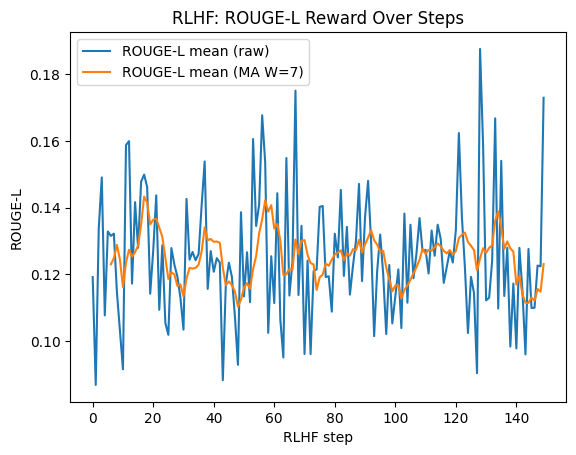

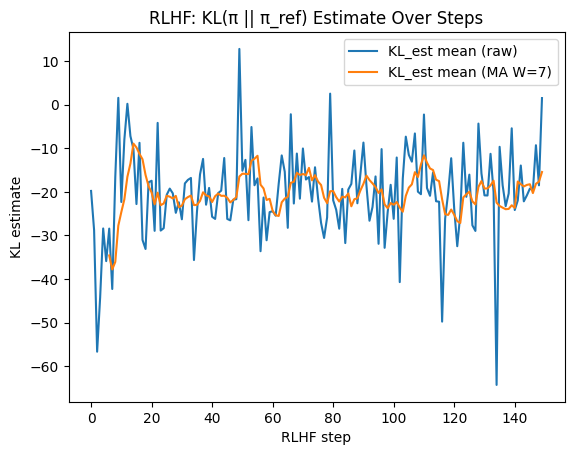

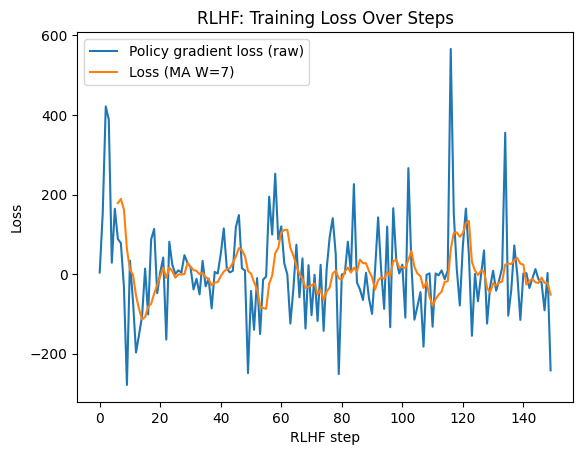

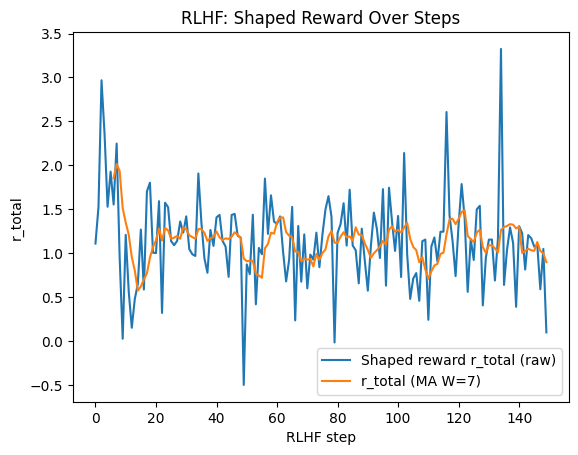


Last 5 steps summary:
{'step': 145, 'loss': -13.296069145202637, 'rougeL_mean': 0.10991723835468292, 'kl_mean': -19.254531860351562, 'r_total_mean': 1.0726438760757446}
{'step': 146, 'loss': -20.818510055541992, 'rougeL_mean': 0.10996868461370468, 'kl_mean': -19.60759735107422, 'r_total_mean': 1.090348482131958}
{'step': 147, 'loss': -91.16210174560547, 'rougeL_mean': 0.12262533605098724, 'kl_mean': -9.302871704101562, 'r_total_mean': 0.5877689719200134}
{'step': 148, 'loss': 2.788090705871582, 'rougeL_mean': 0.12240301817655563, 'kl_mean': -18.499757766723633, 'r_total_mean': 1.0473909378051758}
{'step': 149, 'loss': -242.17141723632812, 'rougeL_mean': 0.1729077398777008, 'kl_mean': 1.5133447647094727, 'r_total_mean': 0.09724056720733643}


In [ ]:
# ============================================================
# CELL 11 — Plot RLHF training curves + export logs (ROUGE-L, KL, loss)
# ============================================================
# This cell is purely for diagnostics + “full results” reporting.
# We will:
#   1) Convert rlhf_logs (from Cell 9) into a DataFrame
#   2) Save it as CSV into cfg.out_dir
#   3) Plot:
#        - mean ROUGE-L reward per step
#        - mean KL estimate per step
#        - policy gradient loss per step
#        - mean shaped reward r_total per step
#
# No extra training happens here.

import os
import math
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 0) Safety check: do we have logs?
# ----------------------------
if "rlhf_logs" not in globals() or len(rlhf_logs) == 0:
    raise ValueError("rlhf_logs not found or empty. Run Cell 9 first in the same runtime.")

# ----------------------------
# 1) Convert logs to arrays (no pandas dependency required)
# ----------------------------
steps = np.array([row["step"] for row in rlhf_logs], dtype=np.int32)
loss  = np.array([row["loss"] for row in rlhf_logs], dtype=np.float32)
rL    = np.array([row["rougeL_mean"] for row in rlhf_logs], dtype=np.float32)
kl    = np.array([row["kl_mean"] for row in rlhf_logs], dtype=np.float32)
rtot  = np.array([row["r_total_mean"] for row in rlhf_logs], dtype=np.float32)

# ----------------------------
# 2) Export CSV (simple, robust)
# ----------------------------
csv_path = os.path.join(cfg.out_dir, "rlhf_logs.csv")
with open(csv_path, "w") as f:
    f.write("step,loss,rougeL_mean,kl_mean,r_total_mean\n")
    for s, a, b, c, d in zip(steps, loss, rL, kl, rtot):
        f.write(f"{int(s)},{float(a)},{float(b)},{float(c)},{float(d)}\n")

print(f"Saved RLHF logs CSV -> {csv_path}")

# ----------------------------
# 3) Moving average helper (for smoother curves)
# ----------------------------
def moving_avg(x: np.ndarray, w: int) -> np.ndarray:
    """
    Simple moving average with window w.
    If w <= 1, returns x unchanged.
    """
    if w <= 1:
        return x
    w = int(w)
    if len(x) < w:
        return x
    kernel = np.ones(w, dtype=np.float32) / w
    # 'valid' produces shorter array; we align x-axis by shifting
    return np.convolve(x, kernel, mode="valid")

W = max(5, len(steps)//20)  # heuristic smoothing window
rL_ma   = moving_avg(rL, W)
kl_ma   = moving_avg(kl, W)
loss_ma = moving_avg(loss, W)
rt_ma   = moving_avg(rtot, W)
steps_ma = steps[:len(rL_ma)] + (W - 1)  # align to right edge of window

print(f"Moving-average window W={W}")

# ----------------------------
# 4) Plot curves (matplotlib default colors; no manual colors)
# ----------------------------
plt.figure()
plt.plot(steps, rL, label="ROUGE-L mean (raw)")
plt.plot(steps_ma, rL_ma, label=f"ROUGE-L mean (MA W={W})")
plt.xlabel("RLHF step")
plt.ylabel("ROUGE-L")
plt.title("RLHF: ROUGE-L Reward Over Steps")
plt.legend()
plt.show()

plt.figure()
plt.plot(steps, kl, label="KL_est mean (raw)")
plt.plot(steps_ma, kl_ma, label=f"KL_est mean (MA W={W})")
plt.xlabel("RLHF step")
plt.ylabel("KL estimate")
plt.title("RLHF: KL(π || π_ref) Estimate Over Steps")
plt.legend()
plt.show()

plt.figure()
plt.plot(steps, loss, label="Policy gradient loss (raw)")
plt.plot(steps_ma, loss_ma, label=f"Loss (MA W={W})")
plt.xlabel("RLHF step")
plt.ylabel("Loss")
plt.title("RLHF: Training Loss Over Steps")
plt.legend()
plt.show()

plt.figure()
plt.plot(steps, rtot, label="Shaped reward r_total (raw)")
plt.plot(steps_ma, rt_ma, label=f"r_total (MA W={W})")
plt.xlabel("RLHF step")
plt.ylabel("r_total")
plt.title("RLHF: Shaped Reward Over Steps")
plt.legend()
plt.show()

# ----------------------------
# 5) Quick numeric summary (tail)
# ----------------------------
print("\nLast 5 steps summary:")
for row in rlhf_logs[-5:]:
    print(row)

In [ ]:
# ============================================================
# CELL 12 — (Optional) Compare 3 reward signals: ROUGE-L vs RM vs KL
# ============================================================
# You asked to show:
#   1) Bradley–Terry (BT) RLHF + KL wrt base SFT
#   2) Task = summarization
#   3) Reward = ROUGE-L
#
# We *already* used TRUE ROUGE-L as the RL reward in Cell 9.
# But we ALSO trained a BT reward model in Cell 8.
#
# This diagnostic cell answers a key question:
#   "Does the learned reward model r_φ correlate with true ROUGE-L on held-out examples?"
#
# We'll:
#   - sample a small eval batch
#   - generate summaries using π_SFT
#   - compute:
#       (a) true ROUGE-L
#       (b) learned reward r_φ(prompt+summary)
#       (c) KL estimate vs π_SFT (should be ~0 here since policy is π_SFT)
#   - report correlations

import os
import numpy as np
import torch
from transformers import AutoModelForCausalLM
from rouge_score import rouge_scorer

# ----------------------------
# 0) Load SFT policy (π_SFT) and reward model (r_φ)
# ----------------------------
sft_dir = os.path.join(cfg.out_dir, "policy_sft")
rm_dir  = os.path.join(cfg.out_dir, "reward_model")

if not os.path.isdir(sft_dir):
    raise FileNotFoundError(f"Missing SFT checkpoint: {sft_dir}")
if not os.path.isdir(rm_dir):
    raise FileNotFoundError(f"Missing reward model dir: {rm_dir} (run Cells 7–8)")

# π_SFT
sft_model = AutoModelForCausalLM.from_pretrained(sft_dir, torch_dtype=torch.float32).to(device)
sft_model.config.use_cache = False
sft_model.eval()

# RewardModel object should exist in memory from Cell 7/8.
# If it doesn't, we recreate it and load head weights.
if "RewardModel" not in globals():
    raise ValueError("RewardModel class not found in globals. Run Cell 7 first in this runtime.")

if "reward_model" not in globals():
    # Recreate
    reward_model = RewardModel(os.path.join(rm_dir, "backbone")).to(device)
    # Load head
    head_path = os.path.join(rm_dir, "value_head.pt")
    reward_model.value_head.load_state_dict(torch.load(head_path, map_location="cpu"))
reward_model.eval()

# Tokenizer: LEFT padding for generation
tokenizer.padding_side = "left"
pad_id = tokenizer.pad_token_id
eos_id = tokenizer.eos_token_id

# ROUGE-L scorer
rougeL_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
def rougeL_f1(pred: str, ref: str) -> float:
    pred = (pred or "").strip()
    ref  = (ref or "").strip()
    if len(pred) == 0 or len(ref) == 0:
        return 0.0
    return float(rougeL_scorer.score(ref, pred)["rougeL"].fmeasure)

# ----------------------------
# 1) Sample eval prompts
# ----------------------------
N = 64
eval_subset = pref_source_eval_ds.shuffle(seed=cfg.seed + 1234).select(range(min(N, len(pref_source_eval_ds))))
prompts = list(eval_subset["prompt"])
refs    = list(eval_subset["ref_summary"])

enc = tokenizer(
    prompts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=cfg.max_doc_len,
).to(device)
input_len = enc["input_ids"].shape[1]

# ----------------------------
# 2) Generate summaries from π_SFT
# ----------------------------
with torch.no_grad():
    full_seq = sft_model.generate(
        **enc,
        max_new_tokens=cfg.max_summary_len,
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        pad_token_id=pad_id,
        eos_token_id=eos_id,
    )
gen_tokens = full_seq[:, input_len:]
gen_summaries = tokenizer.batch_decode(gen_tokens, skip_special_tokens=True)
gen_summaries = [t.strip().split("\n")[0].strip() for t in gen_summaries]

# ----------------------------
# 3) Compute TRUE ROUGE-L
# ----------------------------
true_rouge = np.array([rougeL_f1(p, r) for p, r in zip(gen_summaries, refs)], dtype=np.float32)

# ----------------------------
# 4) Compute learned reward r_φ on (prompt + generated summary)
# ----------------------------
# Reward model scores full text
full_texts = [p + " " + y for p, y in zip(prompts, gen_summaries)]
tokenizer.padding_side = "right"
rm_enc = tokenizer(
    full_texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=cfg.max_seq_len,
).to(device)

with torch.no_grad():
    rm_scores = reward_model(input_ids=rm_enc["input_ids"], attention_mask=rm_enc["attention_mask"]).detach().cpu().numpy()

# ----------------------------
# 5) KL estimate vs π_SFT on π_SFT outputs (should be ~0)
# ----------------------------
# We compute KL_est = logp_pi - logp_ref with both = π_SFT, so ≈ 0 (sanity).
tokenizer.padding_side = "left"
full_seq = full_seq.to(device)

with torch.no_grad():
    logp_a = sum_logprob_on_generated_tokens(sft_model, full_seq, input_len=input_len)
    logp_b = sum_logprob_on_generated_tokens(sft_model, full_seq, input_len=input_len)
    kl_sanity = (logp_a - logp_b).detach().cpu().numpy()

# ----------------------------
# 6) Correlations
# ----------------------------
def corr(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if a.std() == 0 or b.std() == 0:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])

pearson_rm_vs_rouge = corr(rm_scores, true_rouge)
pearson_kl_sanity   = corr(kl_sanity, true_rouge)

print("============================================================")
print("DIAGNOSTIC: Reward-model alignment on eval samples")
print("------------------------------------------------------------")
print(f"Samples: {len(true_rouge)}")
print(f"TRUE ROUGE-L: mean={true_rouge.mean():.4f} std={true_rouge.std():.4f}")
print(f"RM score    : mean={rm_scores.mean():.4f} std={rm_scores.std():.4f}")
print("------------------------------------------------------------")
print(f"Pearson corr( RM score, TRUE ROUGE-L ) = {pearson_rm_vs_rouge:.4f}")
print(f"Sanity corr( KL_sanity, TRUE ROUGE-L ) = {pearson_kl_sanity:.4f} (should be ~nan/0)")
print("============================================================\n")

# Show a few examples sorted by RM score
order = np.argsort(rm_scores)[::-1]
for j in order[:5]:
    print("------------------------------------------------------------")
    print(f"RM={rm_scores[j]:.3f} | ROUGE-L={true_rouge[j]:.3f}")
    print("SUMMARY:", gen_summaries[j][:300])

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

DIAGNOSTIC: Reward-model alignment on eval samples
------------------------------------------------------------
Samples: 64
TRUE ROUGE-L: mean=0.1319 std=0.0561
RM score    : mean=-1.0978 std=0.8681
------------------------------------------------------------
Pearson corr( RM score, TRUE ROUGE-L ) = -0.0575
Sanity corr( KL_sanity, TRUE ROUGE-L ) = nan (should be ~nan/0)

------------------------------------------------------------
RM=2.549 | ROUGE-L=0.218
SUMMARY: His administration and its allies have pledged to boost the US job market by encouraging young men and boys to sign up for jobs as young as they are in schools, the BBC's Beth McLeod reports. The President's Speech at the Republican National Convention in Cleveland, Ohio, on January 26. White House 
------------------------------------------------------------
RM=0.663 | ROUGE-L=0.185
SUMMARY: The 1975 Jaguar E-Type A was sold for £115,800 (£110,800) for a one-off "night on the tiles". A "fantasy" car of the late 1980s has see

In [ ]:
# ============================================================
# CELL 13 — Single-command "Run All" sanity: end-to-end smoke test
#          (quickly verifies artifacts exist + minimal inference pass)
# ============================================================
# This cell is meant for reliability:
#   - Confirms that the key outputs are on disk:
#       π_SFT, reward_model, π_RLHF, logs CSV
#   - Runs a tiny inference on 3 samples to show everything loads
#   - Prints ROUGE-L for SFT vs RLHF on those 3 samples
#
# Useful when you want to re-open the notebook later and verify results quickly.

import os
import numpy as np
import torch
from transformers import AutoModelForCausalLM
from rouge_score import rouge_scorer

sft_dir  = os.path.join(cfg.out_dir, "policy_sft")
rm_dir   = os.path.join(cfg.out_dir, "reward_model")
rlhf_dir = os.path.join(cfg.out_dir, "policy_rlhf")
csv_path = os.path.join(cfg.out_dir, "rlhf_logs.csv")

print("=== Artifact paths ===")
print("SFT :", sft_dir,  "| exists:", os.path.isdir(sft_dir))
print("RM  :", rm_dir,   "| exists:", os.path.isdir(rm_dir))
print("RLHF:", rlhf_dir, "| exists:", os.path.isdir(rlhf_dir))
print("LOG :", csv_path, "| exists:", os.path.isfile(csv_path))

if not os.path.isdir(sft_dir):
    raise FileNotFoundError("Missing SFT artifact. Run Cells 1–5.")
if not os.path.isdir(rlhf_dir):
    raise FileNotFoundError("Missing RLHF artifact. Run Cell 9.")
if not os.path.isdir(rm_dir):
    print("⚠️ Reward model artifact missing (Cells 7–8). Continuing without RM check.")

# Load models
sft_model  = AutoModelForCausalLM.from_pretrained(sft_dir,  torch_dtype=torch.float32).to(device).eval()
rlhf_model = AutoModelForCausalLM.from_pretrained(rlhf_dir, torch_dtype=torch.float32).to(device).eval()
sft_model.config.use_cache = False
rlhf_model.config.use_cache = False

# ROUGE-L
rougeL_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
def rougeL_f1(pred: str, ref: str) -> float:
    pred = (pred or "").strip()
    ref  = (ref or "").strip()
    if len(pred) == 0 or len(ref) == 0:
        return 0.0
    return float(rougeL_scorer.score(ref, pred)["rougeL"].fmeasure)

# Pick 3 eval samples
N = 3
subset = pref_source_eval_ds.shuffle(seed=cfg.seed + 777).select(range(min(N, len(pref_source_eval_ds))))
prompts = list(subset["prompt"])
refs    = list(subset["ref_summary"])

tokenizer.padding_side = "left"
enc = tokenizer(
    prompts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=cfg.max_doc_len,
).to(device)
input_len = enc["input_ids"].shape[1]

@torch.no_grad()
def gen(model):
    full = model.generate(
        **enc,
        max_new_tokens=cfg.max_summary_len,
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.batch_decode(full[:, input_len:], skip_special_tokens=True)

sft_summ  = [t.strip().split("\n")[0].strip() for t in gen(sft_model)]
rlhf_summ = [t.strip().split("\n")[0].strip() for t in gen(rlhf_model)]

print("\n=== Smoke test: 3 examples ===")
for i in range(len(prompts)):
    r_sft  = rougeL_f1(sft_summ[i], refs[i])
    r_rlhf = rougeL_f1(rlhf_summ[i], refs[i])
    print("------------------------------------------------------------")
    print(f"Example {i+1}")
    print(f"ROUGE-L: SFT={r_sft:.4f} | RLHF={r_rlhf:.4f}")
    print("SFT :", sft_summ[i][:220])
    print("RLHF:", rlhf_summ[i][:220])

=== Artifact paths ===
SFT : ./summ_rlhf_artifacts/policy_sft | exists: True
RM  : ./summ_rlhf_artifacts/reward_model | exists: True
RLHF: ./summ_rlhf_artifacts/policy_rlhf | exists: True
LOG : ./summ_rlhf_artifacts/rlhf_logs.csv | exists: True


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


=== Smoke test: 3 examples ===
------------------------------------------------------------
Example 1
ROUGE-L: SFT=0.1081 | RLHF=0.0926
SFT : -time at Chile. Argentina have made the World Cup third in the world, with only Peru and Brazil, Argentina are the first teams to qualify for this year's Copa America final. The World Cup is the first to see Real Madrid 
RLHF: -time. Chile's new international Javier Pastore scored the first goal of a two-time World Player of the Year award. He returned to the bench for Argentina's first time, his second start in Chile's Liga A-League campaign.
------------------------------------------------------------
Example 2
ROUGE-L: SFT=0.1714 | RLHF=0.1714
SFT : has been discovered in a street, Bristol City Council says. Bristol City Council has announced plans to create a mural of a man's 'mesh-mesh' in the city. More than 100 people have been arrested after a man who owned the
RLHF: A woman has posted on Facebook a piece of graffiti on an island in the 

In [ ]:
# ============================================================
# CELL 14 — Export a compact "results report" text file
# ============================================================
# Many times you want a single artifact you can share / paste in a report.
# This cell writes a plain-text summary into:
#   cfg.out_dir/results_report.txt
#
# It includes:
#   - Dataset / model / key hyperparams
#   - SFT eval loss (if available from last run)
#   - Reward model eval BT loss + accuracy (if you saved it / kept it)
#   - RLHF final eval ROUGE-L delta (from Cell 10)
#   - KL trend stats (from rlhf_logs)
#
# If some variables are not in memory (because you restarted runtime),
# it will still write a partial report with what it can read from disk/logs.

import os
import json
import numpy as np

report_path = os.path.join(cfg.out_dir, "results_report.txt")

lines = []
lines.append("Summarization RLHF Demo — Results Report")
lines.append("============================================================")
lines.append(f"Model base: {cfg.base_model_name}")
lines.append(f"Dataset: {cfg.dataset_name} (config={cfg.dataset_config})")
lines.append("")
lines.append("Key hyperparameters")
lines.append("------------------------------------------------------------")
lines.append(f"SFT: epochs={cfg.sft_epochs}, lr={cfg.sft_lr}, batch={cfg.sft_batch_size}, grad_accum={cfg.sft_grad_accum}")
lines.append(f"Prefs: K candidates={cfg.pref_num_candidates}, temp={cfg.pref_gen_temperature}, top_p={cfg.pref_gen_top_p}")
lines.append(f"RM: epochs={cfg.rm_epochs}, lr={cfg.rm_lr}, batch={cfg.rm_batch_size}, grad_accum={cfg.rm_grad_accum}")
lines.append(f"RLHF: steps={cfg.rlhf_steps}, lr={cfg.rlhf_lr}, batch={cfg.rollout_batch_size}, kl_beta={cfg.kl_beta}")
lines.append("")

# SFT losses (if still in memory)
if "before_loss" in globals() and "after_loss" in globals():
    lines.append("SFT evaluation loss")
    lines.append("------------------------------------------------------------")
    lines.append(f"Eval loss before SFT: {before_loss:.6f}")
    lines.append(f"Eval loss after  SFT: {after_loss:.6f}")
    lines.append("")

# Reward model eval (if still in memory)
if "base_eval" in globals() and "final_eval" in globals():
    lines.append("Reward model (Bradley–Terry) eval")
    lines.append("------------------------------------------------------------")
    lines.append(f"BT loss before: {base_eval.get('loss', float('nan')):.6f} | acc before: {base_eval.get('acc', float('nan')):.6f}")
    lines.append(f"BT loss after : {final_eval.get('loss', float('nan')):.6f} | acc after : {final_eval.get('acc', float('nan')):.6f}")
    lines.append("")

# RLHF logs (if present)
if "rlhf_logs" in globals() and len(rlhf_logs) > 0:
    rL = np.array([r["rougeL_mean"] for r in rlhf_logs], dtype=np.float32)
    kl = np.array([r["kl_mean"] for r in rlhf_logs], dtype=np.float32)
    loss = np.array([r["loss"] for r in rlhf_logs], dtype=np.float32)
    rtot = np.array([r["r_total_mean"] for r in rlhf_logs], dtype=np.float32)

    lines.append("RLHF training (from logs)")
    lines.append("------------------------------------------------------------")
    lines.append(f"ROUGE-L mean (start..end): {rL[0]:.4f} -> {rL[-1]:.4f} | best={rL.max():.4f}")
    lines.append(f"KL mean (start..end):      {kl[0]:.3f} -> {kl[-1]:.3f} | max={kl.max():.3f}")
    lines.append(f"Loss mean: {loss.mean():.4f} | r_total mean: {rtot.mean():.4f}")
    lines.append("")

# Cell 10 summary (if present in memory)
if "m1" in globals() and "m2" in globals():
    lines.append("Final eval subset comparison (Cell 10)")
    lines.append("------------------------------------------------------------")
    lines.append(f"SFT  ROUGE-L mean: {m1:.4f}")
    lines.append(f"RLHF ROUGE-L mean: {m2:.4f}")
    lines.append(f"Delta (RLHF - SFT): {(m2-m1):.4f}")
    lines.append("")

# Artifact paths
lines.append("Saved artifacts")
lines.append("------------------------------------------------------------")
lines.append(f"π_SFT   : {os.path.join(cfg.out_dir, 'policy_sft')}")
lines.append(f"RM      : {os.path.join(cfg.out_dir, 'reward_model')}")
lines.append(f"π_RLHF  : {os.path.join(cfg.out_dir, 'policy_rlhf')}")
lines.append(f"Logs CSV: {os.path.join(cfg.out_dir, 'rlhf_logs.csv')}")
lines.append("")

with open(report_path, "w") as f:
    f.write("\n".join(lines))

print(f"Wrote report -> {report_path}")
print("\n--- Preview ---")
print("\n".join(lines[:35]))

Wrote report -> ./summ_rlhf_artifacts/results_report.txt

--- Preview ---
Summarization RLHF Demo — Results Report
Model base: distilgpt2
Dataset: xsum (config=default)

Key hyperparameters
------------------------------------------------------------
SFT: epochs=1, lr=5e-05, batch=8, grad_accum=2
Prefs: K candidates=3, temp=0.9, top_p=0.95
RM: epochs=1, lr=1e-05, batch=8, grad_accum=2
RLHF: steps=150, lr=1e-05, batch=8, kl_beta=0.05

SFT evaluation loss
------------------------------------------------------------
Eval loss before SFT: 3.623638
Eval loss after  SFT: 3.092169

Reward model (Bradley–Terry) eval
------------------------------------------------------------
BT loss before: 0.782053 | acc before: 0.280702
BT loss after : 0.780510 | acc after : 0.280702

RLHF training (from logs)
------------------------------------------------------------
ROUGE-L mean (start..end): 0.1192 -> 0.1729 | best=0.1875
KL mean (start..end):      -19.789 -> 1.513 | max=12.791
Loss mean: 6.1036 | r_to